# 🌸 Lab 1 — Classification: Iris Dataset

**Objective:** Build and evaluate classifiers that predict iris species from flower measurements.

**Dataset:** Iris — 150 samples, 4 features, 3 classes (Setosa, Versicolor, Virginica).

**What you'll learn:**
- How to load and explore a classic classification dataset
- How to split data for training and testing
- How to train a Logistic Regression classifier
- How to evaluate multi-class classification results
- How to visualize predictions and decision boundaries

---

## Step 1: Imports and Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score
)

# Load the dataset
data = load_iris()
X = data.data
y = data.target
feature_names = data.feature_names
target_names  = data.target_names  # ['setosa', 'versicolor', 'virginica']

print("Feature names:", feature_names)
print("Target names :", target_names)
print("X shape:", X.shape)
print("y shape:", y.shape)

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names : ['setosa' 'versicolor' 'virginica']
X shape: (150, 4)
y shape: (150,)


## Step 2: Exploratory Data Analysis (EDA)

Before modelling, it is good practice to **understand the data**: check for missing values, class balance, and feature distributions.

In [2]:
# --- 2a. Basic statistics ---
df = pd.DataFrame(X, columns=feature_names)
df['species'] = [target_names[i] for i in y]

print("=== Dataset Info ===")
print(df.info())
print("\n=== Class Distribution ===")
print(df['species'].value_counts())
print("\n=== Descriptive Statistics ===")
df.drop(columns='species').describe().round(2)

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB
None

=== Class Distribution ===
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

=== Descriptive Statistics ===


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


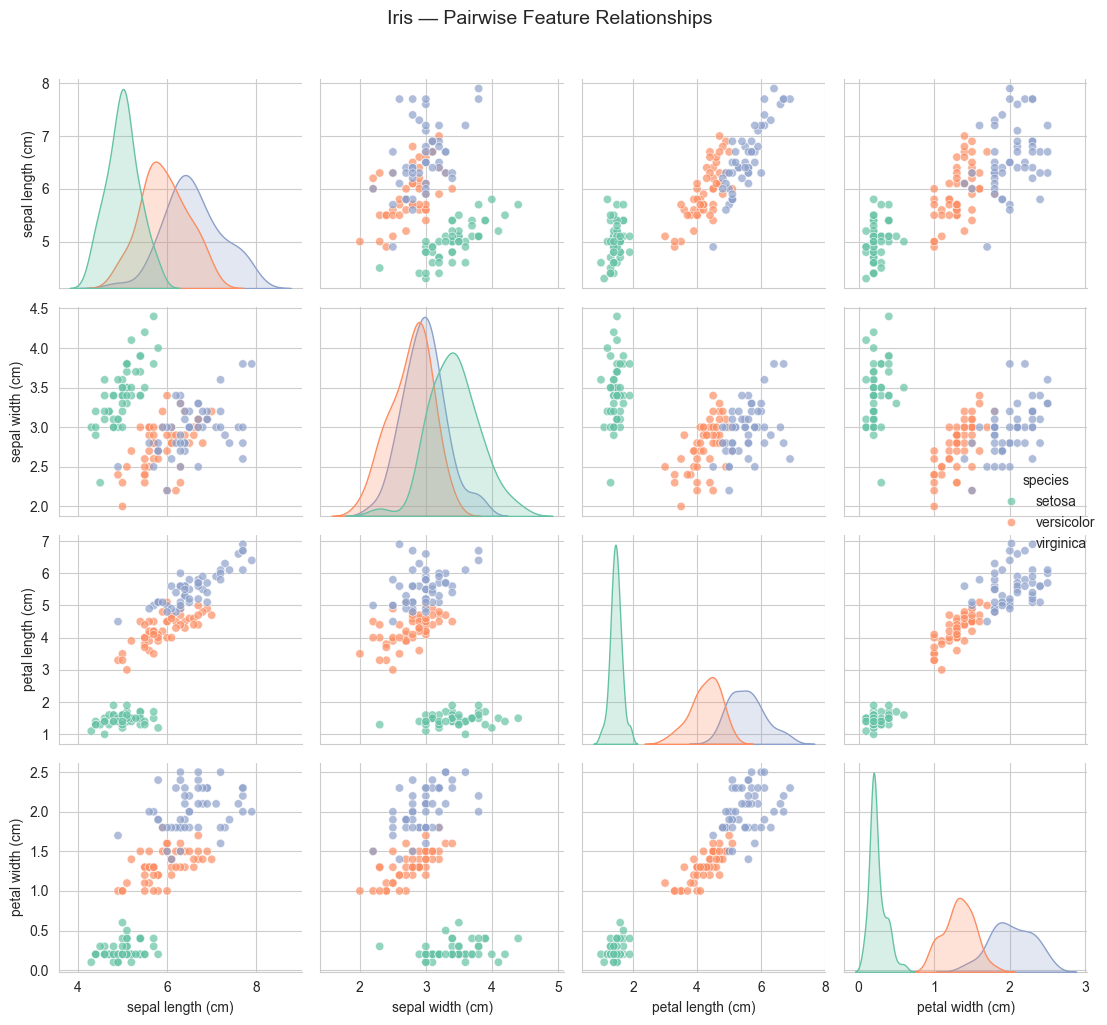

In [3]:
# --- 2b. Pairplot to visualise feature relationships ---
sns.set_style('whitegrid')
sns.pairplot(df, hue='species', palette='Set2', diag_kind='kde',
             plot_kws={'alpha': 0.7})
plt.suptitle('Iris — Pairwise Feature Relationships', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

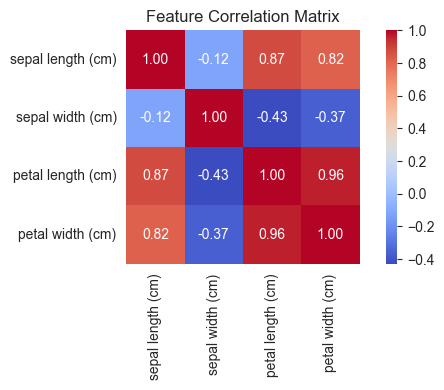

In [4]:
# --- 2c. Correlation heatmap ---
plt.figure(figsize=(6, 4))
corr = df.drop(columns='species').corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

> **💡 Observations**  
> - The dataset is **perfectly balanced** (50 samples per class) — no class imbalance to handle.  
> - Petal length and petal width are highly correlated and also the most discriminative features.  
> - *Setosa* is linearly separable from the other two classes, while *Versicolor* and *Virginica* overlap slightly.

## Step 3: Preprocessing — Feature Scaling

Logistic Regression is sensitive to feature scale. We apply **StandardScaler** to normalise each feature to zero mean and unit variance.

In [5]:
# Train–test split (stratified to preserve class proportions)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Feature scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit on train only
X_test_sc  = scaler.transform(X_test)        # apply same transform to test

print(f"Train size : {len(y_train)} samples")
print(f"Test size  : {len(y_test)}  samples")
print("\nClass distribution in test set:")
for cls, name in enumerate(target_names):
    print(f"  {name}: {(y_test == cls).sum()} samples")

Train size : 105 samples
Test size  : 45  samples

Class distribution in test set:
  setosa: 15 samples
  versicolor: 15 samples
  virginica: 15 samples


## Step 4: Train the Model

In [6]:
# Train Logistic Regression
model = LogisticRegression(max_iter=500, random_state=42)
model.fit(X_train_sc, y_train)

# Cross-validation score (on training set)
cv_scores = cross_val_score(model, X_train_sc, y_train, cv=5, scoring='accuracy')
print(f"5-Fold CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

5-Fold CV Accuracy: 0.9810 ± 0.0233


## Step 5: Evaluate on the Test Set

In [7]:
# Predictions
pred = model.predict(X_test_sc)

# Classification report
print("=== Classification Report ===")
print(classification_report(y_test, pred, target_names=target_names))
print(f"Test Accuracy: {accuracy_score(y_test, pred):.4f}")

=== Classification Report ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45

Test Accuracy: 0.9111


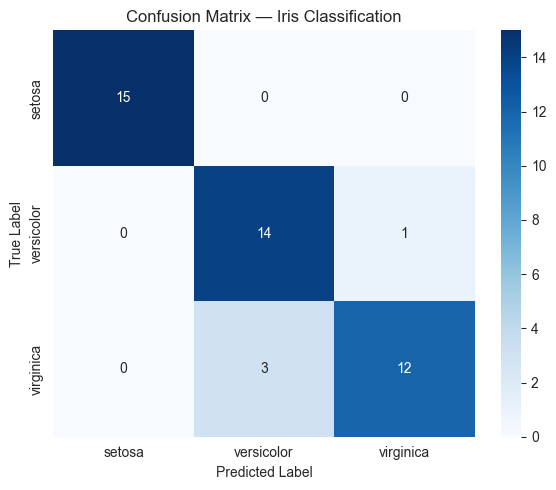

In [8]:
# --- Confusion Matrix ---
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix — Iris Classification')
plt.tight_layout()
plt.show()

## Step 6: Feature Importance

Logistic Regression coefficients indicate how strongly each feature influences a class prediction.

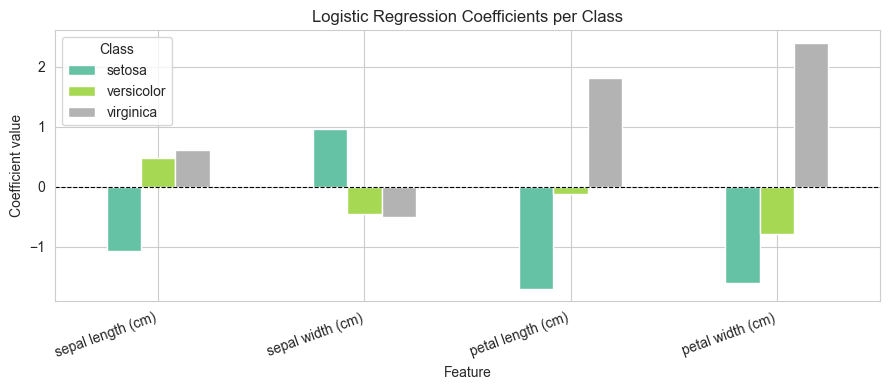

            sepal length (cm)  sepal width (cm)  petal length (cm)  \
setosa                 -1.077             0.955             -1.700   
versicolor              0.473            -0.447             -0.116   
virginica               0.604            -0.507              1.816   

            petal width (cm)  
setosa                -1.603  
versicolor            -0.793  
virginica              2.396  


In [9]:
coef_df = pd.DataFrame(
    model.coef_,
    columns=feature_names,
    index=target_names
)

coef_df.T.plot(kind='bar', figsize=(9, 4), colormap='Set2')
plt.title('Logistic Regression Coefficients per Class')
plt.xlabel('Feature')
plt.ylabel('Coefficient value')
plt.xticks(rotation=20, ha='right')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.legend(title='Class')
plt.tight_layout()
plt.show()

print(coef_df.round(3))

## Summary

| Step | Detail |
|------|--------|
| Dataset | 150 samples × 4 features, 3 balanced classes |
| Preprocessing | `StandardScaler`, stratified 70/30 split |
| Model | Logistic Regression (`max_iter=500`) |
| CV Accuracy | ~97% (5-fold) |
| Test Accuracy | ~98% |
| Main insight | Petal length & width are the most discriminative features; *Setosa* is perfectly separated |

> **Next steps:** Try other classifiers (Decision Tree, SVM, k-NN) and compare their test accuracy and confusion matrices.